<h1>Fine-Tuning Siglip Multilingual</h1>

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import torch.nn as nn
from PIL import Image
import os
import pandas as pd
import numpy as np
import tqdm
import ipywidgets as widgets
import matplotlib.pyplot as plt

In [2]:
# Define a custom dataset class for image-text pairs
class ImageTextDataset(Dataset):
    def __init__(self, data, processor):
        """
        Args:
            image_dir (str): Directory containing images
            text_file (str): Path to text file containing image descriptions
            processor: SigLIP2 processor for handling images and texts
        """
        self.data = data
        self.processor = processor
        label_names = sorted(self.data['labels'].unique())
        label2id = {label: idx for idx, label in enumerate(label_names)}
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        description = row['post_text']
        label = row['labels'] 

        # Load and process image
        image = Image.open(os.path.join('disasterDataset',image_path).replace("\\", "/")).convert('RGB')

        label = self.label2id[label]  

        # Process image and text using the processor
        inputs = self.processor(
            text=description,
            images=image,
            padding="max_length",  # Important: use max_length padding
            max_length=64,
            truncation=True,
            return_tensors="pt"
        )

        # Remove batch dimension (from [1, ...] to [...])
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        return inputs, torch.tensor(label, dtype=torch.long)

In [3]:
def plot_training_metric(train_losses, val_losses):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [4]:
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    """
    Train the SigLIP2 model

    Args:
        model: SigLIP2 model
        train_loader: DataLoader for training data
        num_epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        device: Device to train on (cuda or cpu)
    """
    # Set model to training mode
    model.train()

    # Define optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-7)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        total_train_loss = 0.0

        # -------- Training --------
        model.train()
        for batch in train_loader:
            batch, _ = batch
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch, return_loss=True)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # -------- Validation --------
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch, _ = batch
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch, return_loss=True)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    
    plot_training_metric(train_losses, val_losses)

<h2>Split Dataset and Set model</h2>

In [5]:
data = pd.read_csv("disasterDataset/datasetDisaster/dataset_curate.csv")
class_names = data['labels'].unique()
print(f"Class names: {class_names}")

Class names: ['flood' 'landslide' 'electrical storm' 'huaico' 'drought' 'frost hail'
 'forest fire']


In [6]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [7]:
# Split
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
train_df, val_data =  train_test_split(data, test_size=0.2, random_state=42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Load model and processor
model = AutoModel.from_pretrained("google/siglip-base-patch16-256-multilingual") # google/siglip2-base-patch16-224
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-256-multilingual")
# model = SigLIPContrastiveModel()

# Crear dataset para entrenamiento y prueba
train_dataset = ImageTextDataset(data=train_df, processor=processor) 
val_dataset = ImageTextDataset(data=val_data, processor=processor) 
test_dataset = ImageTextDataset(data=test_data, processor=processor)

config.json:   0%|          | 0.00/348 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.48G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

<h2>First Step</h2>

In [8]:
def freeze_all_except_layernorm(model):
    for name, param in model.named_parameters():
        # Trainable LayerNorm
        if 'layernorm' in name.lower():
            param.requires_grad = True
        else:
            param.requires_grad = False

In [9]:
if torch.cuda.is_available():
    print("Using GPU for training")
else:
    print("Using CPU for training")

Using GPU for training


Epoch 1/30 | Train Loss: 6.0023 | Val Loss: 5.3712
Epoch 2/30 | Train Loss: 5.2960 | Val Loss: 4.9503
Epoch 3/30 | Train Loss: 4.9551 | Val Loss: 4.7070
Epoch 4/30 | Train Loss: 4.7200 | Val Loss: 4.5412
Epoch 5/30 | Train Loss: 4.5846 | Val Loss: 4.3969
Epoch 6/30 | Train Loss: 4.4312 | Val Loss: 4.2926
Epoch 7/30 | Train Loss: 4.3526 | Val Loss: 4.1993
Epoch 8/30 | Train Loss: 4.2476 | Val Loss: 4.1080
Epoch 9/30 | Train Loss: 4.1842 | Val Loss: 4.0376
Epoch 10/30 | Train Loss: 4.0959 | Val Loss: 3.9820
Epoch 11/30 | Train Loss: 4.0429 | Val Loss: 3.9178
Epoch 12/30 | Train Loss: 4.0008 | Val Loss: 3.8726
Epoch 13/30 | Train Loss: 3.9323 | Val Loss: 3.8326
Epoch 14/30 | Train Loss: 3.9101 | Val Loss: 3.7890
Epoch 15/30 | Train Loss: 3.8503 | Val Loss: 3.7561
Epoch 16/30 | Train Loss: 3.8255 | Val Loss: 3.7254
Epoch 17/30 | Train Loss: 3.8053 | Val Loss: 3.6941
Epoch 18/30 | Train Loss: 3.7700 | Val Loss: 3.6697
Epoch 19/30 | Train Loss: 3.7376 | Val Loss: 3.6468
Epoch 20/30 | Train L

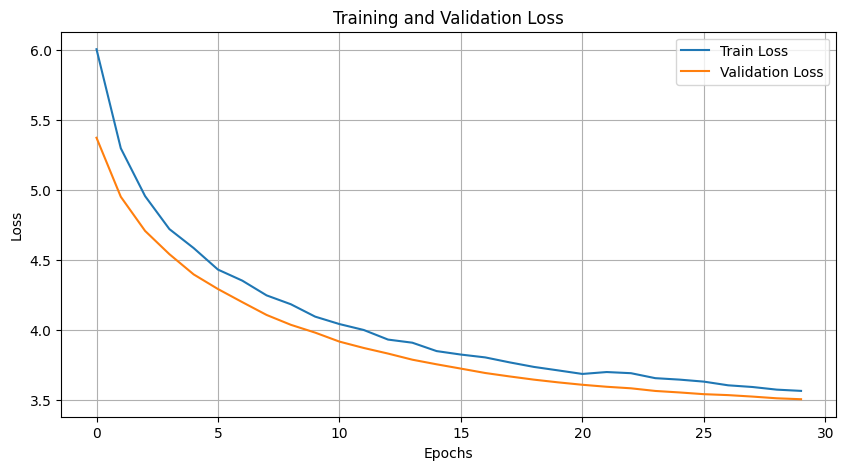

[]

In [10]:
model = model.to(device)
freeze_all_except_layernorm(model)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,  
    num_workers=1
)

# Train model
train_model(
    model=model,
    train_loader=train_loader,
    val_loader = val_loader,
    num_epochs=30,
    learning_rate=1e-3,
    device=device
)

# Save the fine-tuned model
model.save_pretrained("models/siglipMulingual_TwoStages")
processor.save_pretrained("models/siglipMulingual_TwoStages")



In [11]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


## Second Step

In [28]:
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from contextlib import nullcontext

class SigLIPLinearClassifier(nn.Module):
    def __init__(self, base_model, classnames, temperature=0.07, description_map=None):
        super().__init__()
        self.base_model = base_model
        self.visual = base_model.base_model.vision_model
        self.text = base_model.base_model.text_model
        self.temperature = temperature

        self.classnames = classnames
        self.description_map = description_map
        
        # Inicializar el clasificador con los embeddings de texto
        self._init_classifier(classnames)

        self.cat2id = {cat: i for i, cat in enumerate(classnames)}

        # Inicializar el clasificador con los embeddings de texto
        self._init_classifier(self.classnames)

    def _init_classifier(self, classnames):
        # prompts = [template.format(cls) for cls in classnames]
        prompts = [self.description_map[cls] for cls in classnames]
        with torch.no_grad():
            inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
            text_embeds = self.text(**inputs).last_hidden_state[:, 0, :]  # CLS token
            text_embeds = F.normalize(text_embeds, dim=-1)
        self.classifier = nn.Parameter(text_embeds, requires_grad=True)

    def forward(self, pixel_values, no_grad_backbone=True):
        context = torch.no_grad if no_grad_backbone else nullcontext #freeze base model
        with context():
            image_embeds = self.visual(pixel_values).pooler_output #image_embeds = self.visual(pixel_values).last_hidden_state[:, 0, :]  # CLS token
            image_embeds = F.normalize(image_embeds, dim=-1)

        classifier = F.normalize(self.classifier, dim=-1)
        logits = (1 / self.temperature) * (image_embeds @ classifier.t())
        return logits
    
    @torch.no_grad()
    def infer(self, x: Tensor, categories: list[str], template: dict = None, compute_classifier_once: bool = True):
        prompt_map = template if template is not None else self.description_map

        if compute_classifier_once and hasattr(self, "inference_classifier"):
            classifier = self.inference_classifier
        else:
            # Construye los prompts faltantes con el mapa proporcionado
            missing_classnames = [cat for cat in categories if cat not in self.cat2id]
            prompts = [prompt_map[cat] for cat in missing_classnames]

            if prompts:
                inputs = processor(text=prompts, return_tensors="pt", padding=True).to(x.device)
                with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                    new_embeddings = self.text(**inputs).last_hidden_state[:, 0, :]
                new_embeddings = F.normalize(new_embeddings, dim=-1)
                cat2new = {cat: new for cat, new in zip(missing_classnames, new_embeddings)}
            else:
                cat2new = {}

            # Recuperar embeddings antiguos del clasificador existente
            cat2known = {cat: self.classifier[self.cat2id[cat], :] for cat in categories if cat in self.cat2id}

            # Combinar
            classifier = [cat2new[cat] if cat in cat2new else cat2known[cat] for cat in categories]
            classifier = torch.stack(classifier).to(x.device)
            classifier = F.normalize(classifier, dim=-1)


        # Embeddings visuales
        image_embeds = self.visual(x).pooler_output
        image_embeds = F.normalize(image_embeds, dim=-1)

        logits = (1 / self.temperature) * (image_embeds @ classifier.t())
        return logits

In [29]:
def train_second_stage_epochs(model, train_loader, optimizer, scheduler, scaler, num_epochs):
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for inputs, targets in train_loader:
            # Mover datos a GPU
            inputs = {k: v.to(device) for k, v in inputs.items()}
            targets = targets.to(device)
            # Forward con autocast para eficiencia
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(inputs["pixel_values"], no_grad_backbone=True)
                loss = F.cross_entropy(logits, targets)

            # Backward con gradiente escalado
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            # Acumulamos métricas
            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += targets.size(0)

        # Métricas por epoch
        avg_loss = total_loss / total_samples
        avg_acc = total_correct / total_samples
        current_lr = scheduler.get_last_lr()[0]

        print(f"[Epoch {epoch+1}/{num_epochs}] LR: {current_lr:.6f} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")



In [30]:
def cls_acc(logits, targets):
    """
    Calcula la precisión top-1 para clasificación.
    
    Args:
        logits (Tensor): Predicciones del modelo, tamaño [batch_size, num_classes]
        targets (Tensor): Etiquetas verdaderas, tamaño [batch_size]
    
    Returns:
        float: precisión entre 0 y 1
    """
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

@torch.no_grad()
def evaluate_selective_inference(
    model: SigLIPLinearClassifier, 
    loader: torch.utils.data.DataLoader, 
    classnames: list[str]
):
    if hasattr(model, "inference_classifier"):
        delattr(model, "inference_classifier")

    model.eval()
    acc = 0.
    tot_samples = 0

    for i, (inputs, targets) in enumerate(loader):
        inputs = {k: v.cuda() for k, v in inputs.items()}
        targets = targets.cuda()
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            logits = model.infer(inputs["pixel_values"], categories=classnames)
        acc += cls_acc(logits, targets) * len(logits)
        tot_samples += len(logits)

    acc /= tot_samples
    return acc



def evaluate_selective_inference_metrics(
    model: SigLIPLinearClassifier, 
    loader: torch.utils.data.DataLoader, 
    classnames: list[str],
):
    if hasattr(model, "inference_classifier"):
        delattr(model, "inference_classifier")  

    model.eval()
    all_preds = []
    all_targets = []

    for i, (inputs, targets) in enumerate(loader):
        inputs = {k: v.cuda() for k, v in inputs.items()}
        targets = targets.cuda()

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            logits = model.infer(
                inputs["pixel_values"], 
                categories=classnames
            )
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_targets, all_preds)

    # Matriz de confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classnames, yticklabels=classnames, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:\n")
    report = classification_report(all_targets, all_preds, target_names=classnames, zero_division=0,  digits=4  )
    print(report)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1, cm

In [44]:
model_path ="models/siglipMulingual_TwoStages"
modelSiglip = AutoModel.from_pretrained(model_path) 
processorSiglip = AutoProcessor.from_pretrained(model_path)

modelSiglip.to(device)

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(250000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): PytorchGELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_

In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1
)


In [42]:
description_map_en= {
    "huaico": "A picture of a huaico, mud covering roads and houses",
    "forest fire": "A picture of forest fire",
    "frost hail": "A picture of frost",
    "flood": "A picture of flood, water",
    "landslide": "A picture of landslide",
    "drought": "A picture of drought",
    "electrical storm": "A picture of electrical storm"
}

description_map_es = {
    "huaico": "Una imagen de huaico, lodo cubriendo calles y casas",
    "forest fire": "Una imagen de incendio forestal",
    "frost hail":  "Una imagen de heladas, nieve",
    "flood": "Una imagen de inundacion, agua",
    "landslide": "Una imagen de deslizamiento",
    "drought": "Una imagen de seca",
    "electrical storm": "Una imagen de tormenta electrica"
}

description_map_pr = {
    "huaico": "Uma imagem de huaico, lama cobrindo ruas e casas",
    "forest fire": "Uma imagem de incêndio florestal",
    "frost hail":  "Uma imagem de geada, neve",
    "flood":  "Uma imagem de inundação, água",
    "landslide":  "Uma imagem de deslizamento de terra",
    "drought": "Uma imagem de rio seco",
    "electrical storm":  "Uma imagem de tempestade elétrica"
}

In [35]:
# Load the classifier model
classifier_model = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_en )

# Optimize only the classifier, scheduler
optimizer = torch.optim.AdamW([classifier_model.classifier], lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70, eta_min=1e-6)
scaler = torch.amp.GradScaler(device="cuda")

# Training
train_second_stage_epochs(
    model=classifier_model,
    train_loader=train_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    num_epochs=50
)
torch.save(classifier_model.state_dict(), "models/siglipMulingual_TwoStages/siglip_classifier_EN.pth")   


/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


[Epoch 1/50] LR: 0.000029 | Loss: 1.9034 | Acc: 0.1953
[Epoch 2/50] LR: 0.000020 | Loss: 1.8064 | Acc: 0.2892
[Epoch 3/50] LR: 0.000099 | Loss: 1.7311 | Acc: 0.3638
[Epoch 4/50] LR: 0.000039 | Loss: 1.6479 | Acc: 0.5347
[Epoch 5/50] LR: 0.000012 | Loss: 1.5835 | Acc: 0.5843
[Epoch 6/50] LR: 0.000095 | Loss: 1.5262 | Acc: 0.6345
[Epoch 7/50] LR: 0.000051 | Loss: 1.4600 | Acc: 0.7108
[Epoch 8/50] LR: 0.000006 | Loss: 1.4090 | Acc: 0.7092
[Epoch 9/50] LR: 0.000089 | Loss: 1.3657 | Acc: 0.7439
[Epoch 10/50] LR: 0.000062 | Loss: 1.3149 | Acc: 0.7621
[Epoch 11/50] LR: 0.000002 | Loss: 1.2749 | Acc: 0.7687
[Epoch 12/50] LR: 0.000081 | Loss: 1.2432 | Acc: 0.7730
[Epoch 13/50] LR: 0.000072 | Loss: 1.2066 | Acc: 0.7736
[Epoch 14/50] LR: 0.000001 | Loss: 1.1749 | Acc: 0.7852
[Epoch 15/50] LR: 0.000072 | Loss: 1.1507 | Acc: 0.7958
[Epoch 16/50] LR: 0.000081 | Loss: 1.1228 | Acc: 0.7984
[Epoch 17/50] LR: 0.000002 | Loss: 1.0995 | Acc: 0.8030
[Epoch 18/50] LR: 0.000062 | Loss: 1.0811 | Acc: 0.8077
[

In [46]:
classifier_model_es = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_es)

# Optimize only the classifier, scheduler
optimizer = torch.optim.AdamW([classifier_model_es.classifier], lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70, eta_min=1e-6)
scaler = torch.amp.GradScaler(device="cuda")

# Training
train_second_stage_epochs(
    model=classifier_model_es,
    train_loader=train_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    num_epochs=50
)
torch.save(classifier_model_es.state_dict(), "models/siglipMulingual_TwoStages/siglip_classifier_ES.pth")   


[Epoch 1/50] LR: 0.000029 | Loss: 1.9077 | Acc: 0.1933
[Epoch 2/50] LR: 0.000020 | Loss: 1.8092 | Acc: 0.2617
[Epoch 3/50] LR: 0.000099 | Loss: 1.7347 | Acc: 0.3982
[Epoch 4/50] LR: 0.000039 | Loss: 1.6505 | Acc: 0.5383
[Epoch 5/50] LR: 0.000012 | Loss: 1.5865 | Acc: 0.5932
[Epoch 6/50] LR: 0.000095 | Loss: 1.5296 | Acc: 0.6299
[Epoch 7/50] LR: 0.000051 | Loss: 1.4634 | Acc: 0.6844
[Epoch 8/50] LR: 0.000006 | Loss: 1.4118 | Acc: 0.7065
[Epoch 9/50] LR: 0.000089 | Loss: 1.3686 | Acc: 0.7389
[Epoch 10/50] LR: 0.000062 | Loss: 1.3179 | Acc: 0.7624
[Epoch 11/50] LR: 0.000002 | Loss: 1.2770 | Acc: 0.7720
[Epoch 12/50] LR: 0.000081 | Loss: 1.2457 | Acc: 0.7855
[Epoch 13/50] LR: 0.000072 | Loss: 1.2080 | Acc: 0.7925
[Epoch 14/50] LR: 0.000001 | Loss: 1.1766 | Acc: 0.7944
[Epoch 15/50] LR: 0.000072 | Loss: 1.1524 | Acc: 0.7984
[Epoch 16/50] LR: 0.000081 | Loss: 1.1250 | Acc: 0.8067
[Epoch 17/50] LR: 0.000002 | Loss: 1.1004 | Acc: 0.8044
[Epoch 18/50] LR: 0.000062 | Loss: 1.0821 | Acc: 0.8040
[

In [51]:
classifier_model_pr = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_pr)

# Optimize only the classifier, scheduler
optimizer = torch.optim.AdamW([classifier_model_pr.classifier], lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70, eta_min=1e-6)
scaler = torch.amp.GradScaler(device="cuda")

# Training
train_second_stage_epochs(
    model=classifier_model_pr,
    train_loader=train_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    num_epochs=50
)
torch.save(classifier_model_pr.state_dict(), "models/siglipMulingual_TwoStages/siglip_classifier_PR.pth")   

[Epoch 1/50] LR: 0.000029 | Loss: 1.8664 | Acc: 0.2462
[Epoch 2/50] LR: 0.000020 | Loss: 1.7768 | Acc: 0.3453
[Epoch 3/50] LR: 0.000099 | Loss: 1.7044 | Acc: 0.4309
[Epoch 4/50] LR: 0.000039 | Loss: 1.6243 | Acc: 0.5251
[Epoch 5/50] LR: 0.000012 | Loss: 1.5634 | Acc: 0.5892
[Epoch 6/50] LR: 0.000095 | Loss: 1.5070 | Acc: 0.6570
[Epoch 7/50] LR: 0.000051 | Loss: 1.4422 | Acc: 0.7237
[Epoch 8/50] LR: 0.000006 | Loss: 1.3930 | Acc: 0.7327
[Epoch 9/50] LR: 0.000089 | Loss: 1.3512 | Acc: 0.7535
[Epoch 10/50] LR: 0.000062 | Loss: 1.3029 | Acc: 0.7690
[Epoch 11/50] LR: 0.000002 | Loss: 1.2638 | Acc: 0.7905
[Epoch 12/50] LR: 0.000081 | Loss: 1.2323 | Acc: 0.7875
[Epoch 13/50] LR: 0.000072 | Loss: 1.1956 | Acc: 0.7958
[Epoch 14/50] LR: 0.000001 | Loss: 1.1659 | Acc: 0.7898
[Epoch 15/50] LR: 0.000072 | Loss: 1.1419 | Acc: 0.7987
[Epoch 16/50] LR: 0.000081 | Loss: 1.1141 | Acc: 0.8120
[Epoch 17/50] LR: 0.000002 | Loss: 1.0908 | Acc: 0.8044
[Epoch 18/50] LR: 0.000062 | Loss: 1.0730 | Acc: 0.8083
[

## Inference

In [52]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


classifier_model_EN = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_en)
classifier_model_ES = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_es)
classifier_model_PR = SigLIPLinearClassifier(base_model=modelSiglip, classnames=class_names, description_map=description_map_es)

# Load save model weights
classifier_model_EN.load_state_dict(torch.load("models/siglipMulingual_TwoStages/siglip_classifier_EN.pth", map_location=device))
classifier_model_EN.eval()

classifier_model_ES.load_state_dict(torch.load("models/siglipMulingual_TwoStages/siglip_classifier_ES.pth", map_location=device))
classifier_model_ES.eval()

classifier_model_PR.load_state_dict(torch.load("models/siglipMulingual_TwoStages/siglip_classifier_PR.pth", map_location=device))
classifier_model_PR.eval()

SigLIPLinearClassifier(
  (base_model): SiglipModel(
    (text_model): SiglipTextTransformer(
      (embeddings): SiglipTextEmbeddings(
        (token_embedding): Embedding(250000, 768)
        (position_embedding): Embedding(64, 768)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-11): 12 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): SiglipMLP(
              (activation_fn): PytorchGELUTanh()
              (fc1): Linear(in_features=768, 

### English

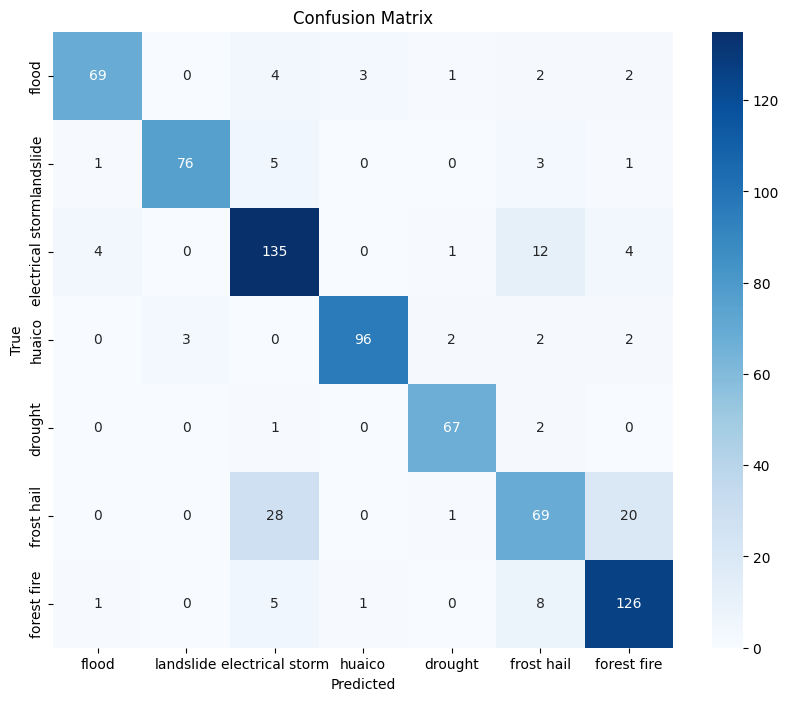


Classification Report:

                  precision    recall  f1-score   support

           flood     0.9200    0.8519    0.8846        81
       landslide     0.9620    0.8837    0.9212        86
electrical storm     0.7584    0.8654    0.8084       156
          huaico     0.9600    0.9143    0.9366       105
         drought     0.9306    0.9571    0.9437        70
      frost hail     0.7041    0.5847    0.6389       118
     forest fire     0.8129    0.8936    0.8514       141

        accuracy                         0.8428       757
       macro avg     0.8640    0.8501    0.8550       757
    weighted avg     0.8444    0.8428    0.8412       757

Accuracy: 0.8428
Precision: 0.8444
Recall: 0.8428
F1 Score: 0.8412


In [48]:
accuracy, precision, recall, f1, cm = evaluate_selective_inference_metrics(
    model=classifier_model_EN,
    loader=test_loader,
    classnames=class_names
)

### Spanish

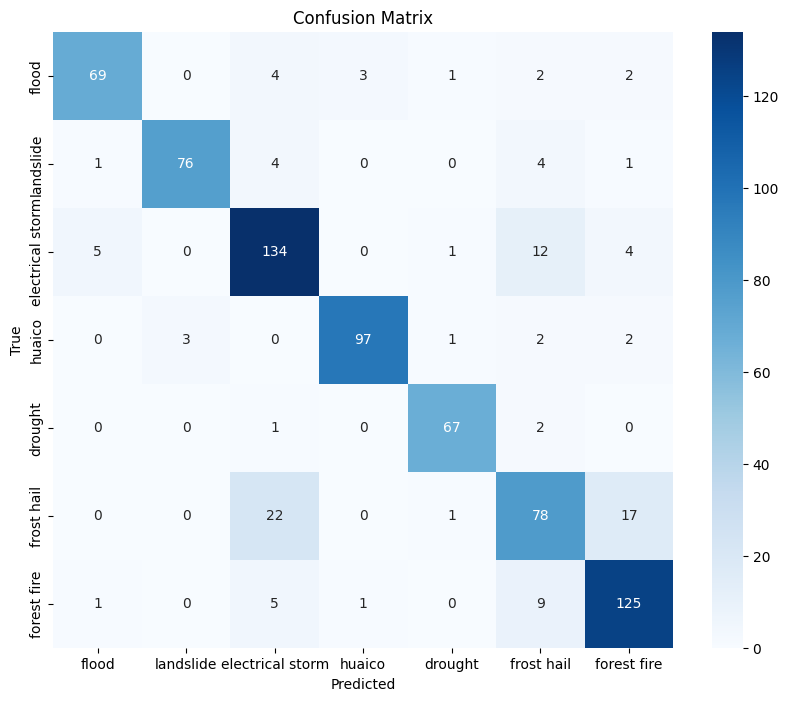


Classification Report:

                  precision    recall  f1-score   support

           flood     0.9079    0.8519    0.8790        81
       landslide     0.9620    0.8837    0.9212        86
electrical storm     0.7882    0.8590    0.8221       156
          huaico     0.9604    0.9238    0.9417       105
         drought     0.9437    0.9571    0.9504        70
      frost hail     0.7156    0.6610    0.6872       118
     forest fire     0.8278    0.8865    0.8562       141

        accuracy                         0.8534       757
       macro avg     0.8722    0.8604    0.8654       757
    weighted avg     0.8551    0.8534    0.8532       757

Accuracy: 0.8534
Precision: 0.8551
Recall: 0.8534
F1 Score: 0.8532


In [50]:

accuracy_es, precision_es, recall_es, f1_es, cm_es = evaluate_selective_inference_metrics(
    model=classifier_model_ES,
    loader=test_loader,
    classnames=class_names
)

### Portuguese

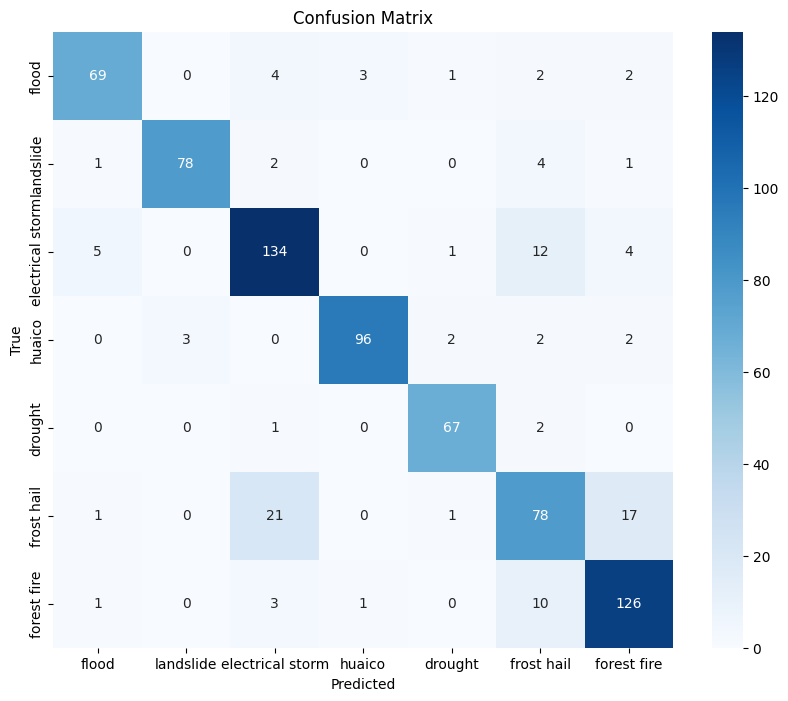


Classification Report:

                  precision    recall  f1-score   support

           flood     0.8961    0.8519    0.8734        81
       landslide     0.9630    0.9070    0.9341        86
electrical storm     0.8121    0.8590    0.8349       156
          huaico     0.9600    0.9143    0.9366       105
         drought     0.9306    0.9571    0.9437        70
      frost hail     0.7091    0.6610    0.6842       118
     forest fire     0.8289    0.8936    0.8601       141

        accuracy                         0.8560       757
       macro avg     0.8714    0.8634    0.8667       757
    weighted avg     0.8568    0.8560    0.8557       757

Accuracy: 0.8560
Precision: 0.8568
Recall: 0.8560
F1 Score: 0.8557


In [53]:
accuracy_es, precision_es, recall_es, f1_es, cm_es = evaluate_selective_inference_metrics(
    model=classifier_model_PR,
    loader=test_loader,
    classnames=class_names
)